In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/_data.csv")
df = df.drop(['Unnamed: 0'], axis=1)

df.head()

,ID объявления,Количество комнат,Тип,Метро,Адрес,"Площадь, м2",Дом,Парковка,Цена,Телефоны,Описание,Ремонт,"Площадь комнат, м2",Балкон,Окна,Санузел,Можно с детьми/животными,Дополнительно,Название ЖК,Серия дома,"Высота потолков, м",Лифт,Мусоропровод,Ссылка на объявление
0,271271157,4,Квартира,м. Смоленская (9 мин пешком),"Москва, улица Новый Арбат, 27",200.0/20.0,"5/16, Монолитный",подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...",+79166369231,Без комиссии для нанимателя! Бонус коллегам 12...,Дизайнерский,NaN,NaN,NaN,NaN,"Можно с детьми, Можно с животными","Мебель в комнатах, Мебель на кухне, Ванна, Душ...","Новый Арбат, 2010",NaN,3.0,"Пасс (4), Груз (1)",Да,https://www.cian.ru/rent/flat/271271157
1,271634126,4,Квартира,м. Смоленская (8 мин пешком),"Москва, улица Новый Арбат, 27",198.0/95.0/18.0,"5/16, Монолитно-кирпичный",подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...",+79850608590,Лот 93107. Елена Анисимова.\n\nБонус агенту 50...,Дизайнерский,25 25 20 25,NaN,На улицу и двор,"Совмещенный (2), Раздельный (1)",Можно с детьми,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",Новый Арбат,NaN,3.5,"Пасс (1), Груз (1)",Нет,https://www.cian.ru/rent/flat/271634126
2,271173086,"4, Оба варианта",Квартира,м. Смоленская (7 мин пешком),"Москва, улица Новый Арбат, 27",200.0/116.0/4.0,5/16,подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...","+79672086536, +79099269384","ID 36380: Шикарная 4-х км. квартира в ЖК ""Нов...",Евроремонт,NaN,NaN,На улицу и двор,Совмещенный (3),Можно с детьми,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",Новый Арбат,NaN,3.2,Пасс (1),NaN,https://www.cian.ru/rent/flat/271173086
3,272197456,"4, Оба варианта",Квартира,м. Смоленская (3 мин пешком),"Москва, переулок Плотников, 21С1",170.0/95.0/17.0,5/6,подземная,"400000.0 руб./ За месяц, Залог - 400000 руб., ...","+79660342340, +79099269384",ID 31618: Эксклюзивное предложение. Современн...,Евроремонт,14-42-20-19,NaN,На улицу и двор,Совмещенный (3),Можно с животными,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",NaN,NaN,3.2,Пасс (1),NaN,https://www.cian.ru/rent/flat/272197456
4,273614615,2,Квартира,м. Арбатская (7 мин пешком),"Москва, улица Новый Арбат, 15",58.0/38.0/5.0,"12/26, Панельный",NaN,"225000.0 руб./ За месяц, Залог - 225000 руб., ...",+79852432860,Лот 111542. Татьяна Лучкина.\n\nБонус агенту 5...,Евроремонт,20 18,NaN,На улицу и двор,Совмещенный (2),NaN,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",The Book,NaN,3.9,"Пасс (1), Груз (1)",Да,https://www.cian.ru/rent/flat/273614615


In [3]:
rooms = df['Количество комнат'].astype(str).str.extract(r'(\d+)')[0].astype('Int64')
price_per_month = df['Цена'].str.extract(r'(\d+\.?\d*)\s*руб\./\s*За\s*месяц')[0].astype(float)
area = df['Площадь, м2'].str.split('/').str[0].astype(float)
floor = df['Дом'].astype(str).str.extract(r'(\d+)')[0].astype('Int64')

Исходное количество записей: 22303
Границы цены: от 19,000 до 600,000 руб.
Границы площади: от 22.0 до 238.0 м²
После фильтрации: 21542 записей
Удалено выбросов: 761 (3.4%)


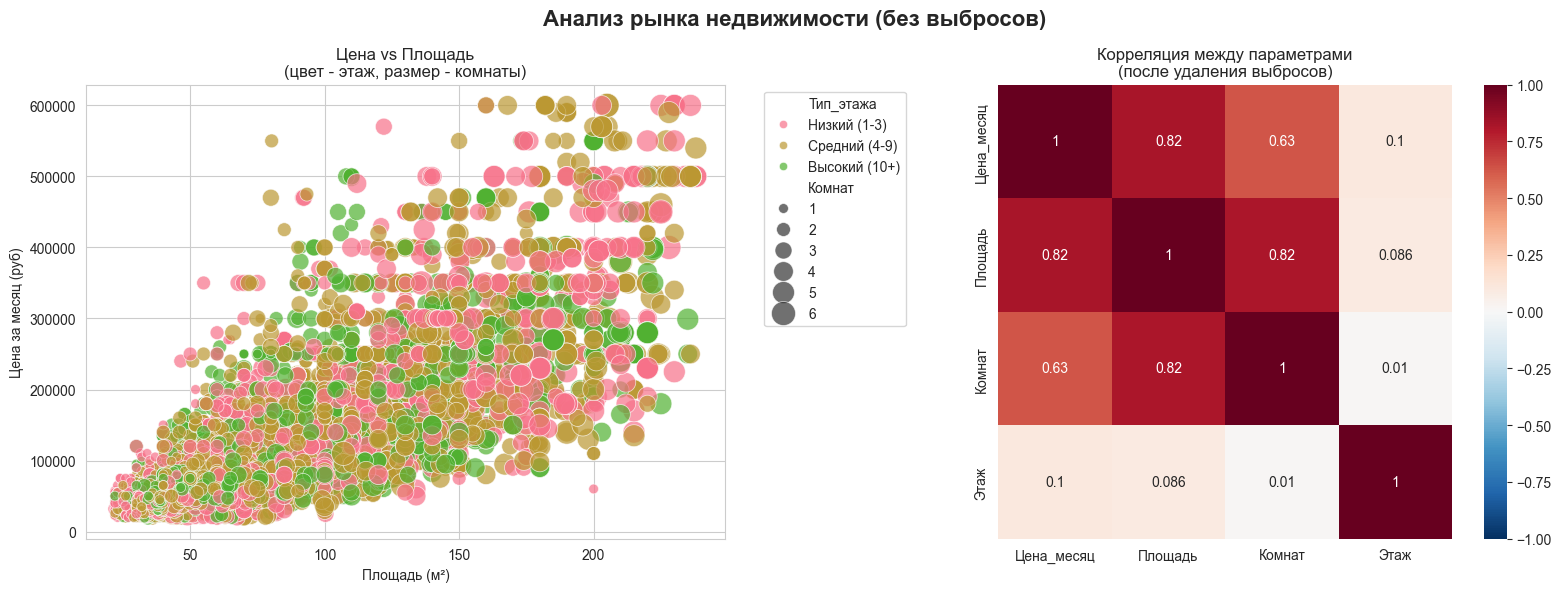

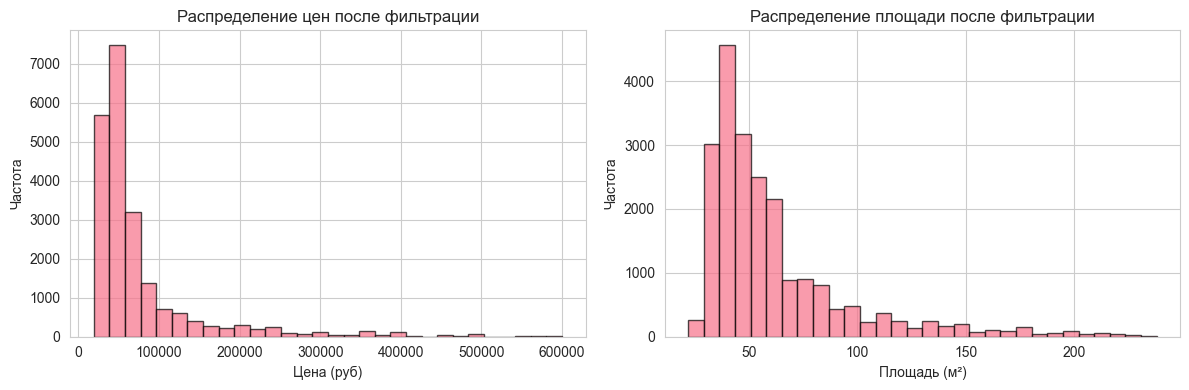

In [4]:
# Создаем DataFrame с вашими очищенными данными
df_clean = pd.DataFrame({
    'Цена_месяц': price_per_month,
    'Площадь': area,
    'Комнат': rooms,
    'Этаж': floor
})

# Удаляем пропуски если есть
df_clean = df_clean.dropna()

# ПРИМЕНЯЕМ ФИЛЬТРАЦИЮ ПО ПЕРЦЕНТИЛЯМ
print(f"Исходное количество записей: {len(df_clean)}")

# Вычисляем перцентили
price_p1 = df_clean['Цена_месяц'].quantile(0.01)
price_p99 = df_clean['Цена_месяц'].quantile(0.99)
area_p1 = df_clean['Площадь'].quantile(0.01)
area_p99 = df_clean['Площадь'].quantile(0.99)

print(f"Границы цены: от {price_p1:,.0f} до {price_p99:,.0f} руб.")
print(f"Границы площади: от {area_p1:.1f} до {area_p99:.1f} м²")

# Применяем фильтр
mask = (
    (df_clean['Цена_месяц'] >= price_p1) & (df_clean['Цена_месяц'] <= price_p99) &
    (df_clean['Площадь'] >= area_p1) & (df_clean['Площадь'] <= area_p99)
)

df_clean_filtered = df_clean[mask].copy()  # .copy() чтобы избежать предупреждений

print(f"После фильтрации: {len(df_clean_filtered)} записей")
print(f"Удалено выбросов: {len(df_clean) - len(df_clean_filtered)} "
      f"({((len(df_clean) - len(df_clean_filtered))/len(df_clean)*100):.1f}%)")

# Создаем категории для наглядности (работаем с отфильтрованными данными)
df_clean_filtered['Тип_этажа'] = pd.cut(df_clean_filtered['Этаж'], 
                               bins=[0, 3, 9, 33],
                               labels=['Низкий (1-3)', 'Средний (4-9)', 'Высокий (10+)'])

# Настройка стиля
sns.set_style("whitegrid")
sns.set_palette("husl")

# Создаем сетку из 1x2 графиков
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Анализ рынка недвижимости (без выбросов)', fontsize=16, fontweight='bold')

# 1. Главный график: Цена vs Площадь (размер = комнаты, цвет = этаж)
scatter = sns.scatterplot(
    data=df_clean_filtered, 
    x='Площадь', 
    y='Цена_месяц',
    hue='Тип_этажа',
    size='Комнат',
    sizes=(50, 300),
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Цена vs Площадь\n(цвет - этаж, размер - комнаты)', fontsize=12)
axes[0].set_xlabel('Площадь (м²)')
axes[0].set_ylabel('Цена за месяц (руб)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Тепловая карта корреляций
numeric_cols = ['Цена_месяц', 'Площадь', 'Комнат', 'Этаж']
corr_matrix = df_clean_filtered[numeric_cols].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='RdBu_r',
    center=0,
    square=True,
    ax=axes[1],
    vmin=-1, vmax=1  # Добавил границы для корреляции
)
axes[1].set_title('Корреляция между параметрами\n(после удаления выбросов)', fontsize=12)

plt.tight_layout()
plt.show()

# Дополнительно: гистограммы для проверки распределения после фильтрации
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean_filtered['Цена_месяц'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение цен после фильтрации')
axes[0].set_xlabel('Цена (руб)')
axes[0].set_ylabel('Частота')

axes[1].hist(df_clean_filtered['Площадь'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение площади после фильтрации')
axes[1].set_xlabel('Площадь (м²)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

📊 Статистика по количеству комнат:
 Количество комнат  Количество объявлений
                 1                   7931
                 2                   8466
                 3                   4262
                 4                   1163
                 5                    367
                 6                    138


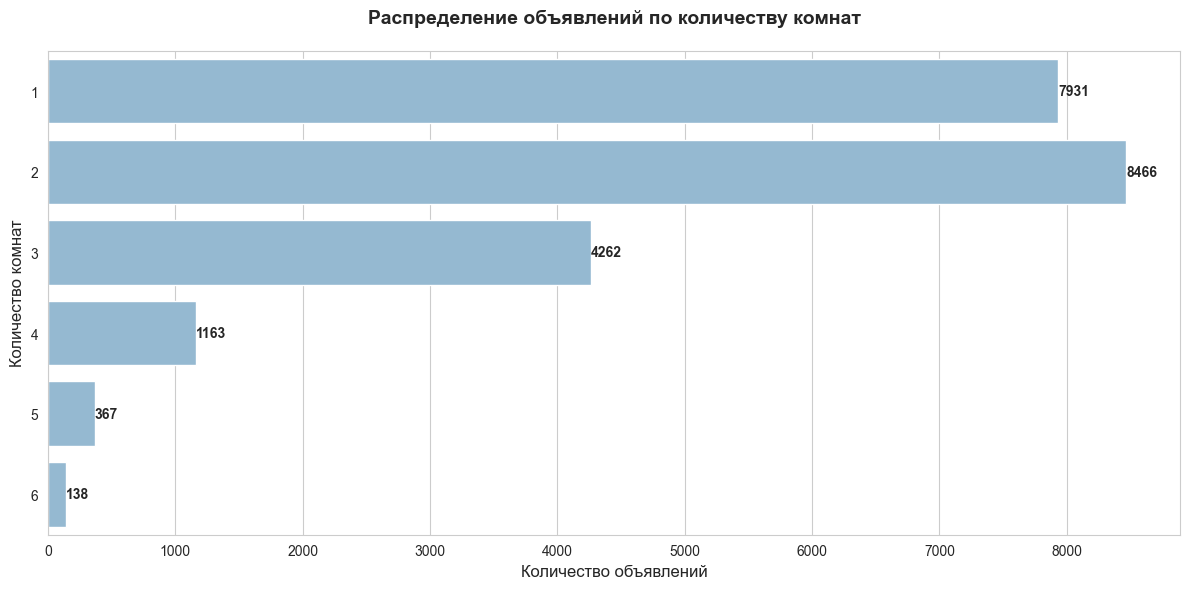

In [5]:
# Ваши очищенные данные
df_clean = pd.DataFrame({
    'Количество комнат': rooms,
    'Цена': price_per_month,
    'Площадь': area,
    'Этаж': floor
})

# Удаляем пропуски если есть
df_clean = df_clean.dropna(subset=['Количество комнат'])

# Подсчитываем количество объявлений по комнатам
room_counts = df_clean['Количество комнат'].value_counts().sort_index().reset_index()
room_counts.columns = ['Количество комнат', 'Количество объявлений']

print("📊 Статистика по количеству комнат:")
print(room_counts.to_string(index=False))

# 1. Простой горизонтальный барплот
plt.figure(figsize=(12, 6))

sns.set_style("whitegrid")
sns.set_palette("Blues_d")

# Горизонтальный барплот
sns.barplot(data=room_counts, 
            y='Количество комнат', 
            x='Количество объявлений',
            orient='h')

plt.title('Распределение объявлений по количеству комнат', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Количество объявлений', fontsize=12)
plt.ylabel('Количество комнат', fontsize=12)

# Добавляем значения на столбцы
for i, (_, row) in enumerate(room_counts.iterrows()):
    plt.text(row['Количество объявлений'] + 0.5, i, 
             f"{int(row['Количество объявлений'])}", 
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
# Данные
rooms = [1, 2, 3, 4, 5, 6]
counts = [7931, 8466, 4262, 1163, 367, 138]
total = sum(counts)

# Расчет долей
percentages = [c/total*100 for c in counts]

print("📊 АНАЛИЗ РАСПРЕДЕЛЕНИЯ")
print("="*60)
for r, c, p in zip(rooms, counts, percentages):
    print(f"{r} комн.: {c:>4} шт. ({p:>5.1f}%)")
print("="*60)
print(f"ВСЕГО: {total} объявлений")

📊 АНАЛИЗ РАСПРЕДЕЛЕНИЯ
1 комн.: 7931 шт. ( 35.5%)
2 комн.: 8466 шт. ( 37.9%)
3 комн.: 4262 шт. ( 19.1%)
4 комн.: 1163 шт. (  5.2%)
5 комн.:  367 шт. (  1.6%)
6 комн.:  138 шт. (  0.6%)
ВСЕГО: 22327 объявлений


📊 СТАТИСТИКА ПО КОМНАТАМ:
 Количество комнат  Количество объявлений  Ср. цена  Мед. цена  Мин. цена  Макс. цена  Стд. откл.
                 1                   7931   39488.0    36000.0    10000.0    300000.0     17133.0
                 2                   8466   61546.0    50000.0    14000.0   1050000.0     44355.0
                 3                   4262  121144.0    82750.0    20000.0   1775000.0    111135.0
                 4                   1163  265870.0   205000.0    22000.0   2500000.0    228944.0
                 5                    367  421462.0   330000.0    39999.0   3000000.0    332274.0
                 6                    138  660775.0   590000.0    65000.0   3000000.0    475970.0


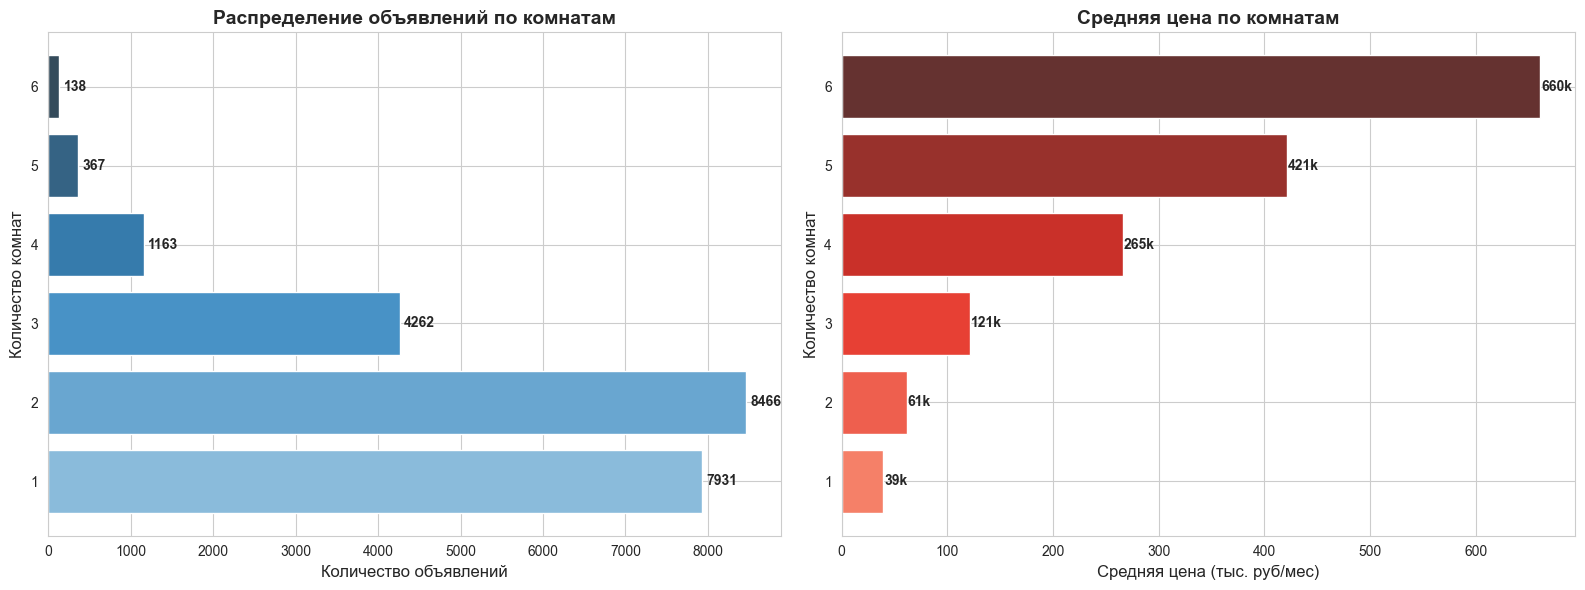

In [7]:

# Группировка по комнатам
room_stats = df_clean.groupby('Количество комнат').agg({
    'Количество комнат': 'count',
    'Цена': ['mean', 'median', 'min', 'max', 'std']
}).round(0)

# Переименовываем колонки
room_stats.columns = ['Количество объявлений', 'Ср. цена', 'Мед. цена', 'Мин. цена', 'Макс. цена', 'Стд. откл.']
room_stats = room_stats.reset_index()

print("📊 СТАТИСТИКА ПО КОМНАТАМ:")
print("="*80)
print(room_stats.to_string(index=False))
print("="*80)

# Создаем график
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Настройка стиля
sns.set_style("whitegrid")

# 1. Горизонтальный барплот (количество объявлений)
ax1 = axes[0]
colors1 = sns.color_palette("Blues_d", len(room_stats))
bars1 = ax1.barh(room_stats['Количество комнат'].astype(str), 
                 room_stats['Количество объявлений'],
                 color=colors1)
ax1.set_xlabel('Количество объявлений', fontsize=12)
ax1.set_ylabel('Количество комнат', fontsize=12)
ax1.set_title('Распределение объявлений по комнатам', 
              fontsize=14, fontweight='bold')

# Добавляем значения
for i, (_, row) in enumerate(room_stats.iterrows()):
    ax1.text(row['Количество объявлений'] + 50, i, 
             f"{int(row['Количество объявлений'])}", 
             va='center', fontweight='bold')

# 2. Горизонтальный барплот (средняя цена)
ax2 = axes[1]
colors2 = sns.color_palette("Reds_d", len(room_stats))
bars2 = ax2.barh(room_stats['Количество комнат'].astype(str), 
                 room_stats['Ср. цена']/1000,  # в тысячах для читаемости
                 color=colors2)
ax2.set_xlabel('Средняя цена (тыс. руб/мес)', fontsize=12)
ax2.set_ylabel('Количество комнат', fontsize=12)
ax2.set_title('Средняя цена по комнатам', 
              fontsize=14, fontweight='bold')

# Добавляем значения
for i, (_, row) in enumerate(room_stats.iterrows()):
    ax2.text(row['Ср. цена']/1000 + 1, i, 
             f"{int(row['Ср. цена']/1000)}k", 
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# Данные
rooms = [1, 2, 3, 4, 5, 6]
counts = [7931, 8466, 4262, 1163, 367, 138]
prices = [39, 61, 121, 265, 421, 860]  # в тыс. руб
total = sum(counts)

print("="*70)
print("📊 АНАЛИЗ РЫНКА АРЕНДЫ".center(70))
print("="*70)

# 1. Основная статистика
for r, c, p in zip(rooms, counts, prices):
    share = (c/total)*100
    print(f"{r} комн.: {c:>4} шт. ({share:>5.1f}%) | Средняя цена: {p:>3}k руб")

                        📊 АНАЛИЗ РЫНКА АРЕНДЫ                         
1 комн.: 7931 шт. ( 35.5%) | Средняя цена:  39k руб
2 комн.: 8466 шт. ( 37.9%) | Средняя цена:  61k руб
3 комн.: 4262 шт. ( 19.1%) | Средняя цена: 121k руб
4 комн.: 1163 шт. (  5.2%) | Средняя цена: 265k руб
5 комн.:  367 шт. (  1.6%) | Средняя цена: 421k руб
6 комн.:  138 шт. (  0.6%) | Средняя цена: 860k руб


In [9]:
# Примерные площади (типичные для рынка)
typical_area = {1: 32, 2: 45, 3: 60, 4: 80, 5: 100, 6: 120}

print("\n📐 ЦЕНА ЗА КВАДРАТНЫЙ МЕТР:")
for r, p in zip(rooms, prices):
    price_per_m2 = (p * 1000) / typical_area[r]
    print(f"{r}к: {price_per_m2:.0f} руб/м²")


📐 ЦЕНА ЗА КВАДРАТНЫЙ МЕТР:
1к: 1219 руб/м²
2к: 1356 руб/м²
3к: 2017 руб/м²
4к: 3312 руб/м²
5к: 4210 руб/м²
6к: 7167 руб/м²
